In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import statsmodels.api as sm
from statsmodels.formula.api import ols

In [2]:
# Read the analysis results
pt_results_dirpath = "data/pt-sim-results/"

pt_scenarios_results = pd.read_csv(os.path.join(pt_results_dirpath, "all_pt_scenario_level_analysis_results.csv"))
pt_scenarios_results.head()

,average_journey_time,average_pt_service_rate,average_intracity_journey_time,average_intercity_journey_time,pt_network_name,train_headway,bus_headway,demand_size,intra_ratio,random_seed
0,4813.31,1.00,NaN,4813.3100,basic,10,10,100,0,3
1,4613.07,1.00,NaN,4613.0700,basic,10,10,100,0,6
2,4682.95,1.00,NaN,4682.9500,basic,10,10,100,0,9
3,4383.16,0.96,2937.75,4744.5125,basic,10,10,100,20,3
4,4223.76,0.96,2540.65,4644.5375,basic,10,10,100,20,6


In [3]:
print(pt_scenarios_results.columns)

Index(['average_journey_time', 'average_pt_service_rate',
       'average_intracity_journey_time', 'average_intercity_journey_time',
       'pt_network_name', 'train_headway', 'bus_headway', 'demand_size',
       'intra_ratio', 'random_seed'],
      dtype='object')


# Variables

In [4]:
# BUS Network
bus_network_list = ['basic', 'diagonal', 'ring', 'mature']
# Train Headway (min)
train_headway_list = [10, 20, 30]

# Random Seed
random_seed_list = [3, 6, 9]

# Demand Size
demand_size_list = [i for i in range(100, 1001, 100)]
# Demand Split Ratio (Intra Modal, %)
demand_split_ratio_list = [0, 20, 40, 60, 80]

variable_name_list = ['random_seed', 'demand_size', 'intra_ratio', 'train_headway']

name_dict = {
    'random_seed': 'Random Seed',
    'demand_size': 'Demand Size',
    'intra_ratio': "Intra Demand Ratio",
    'pt_network_name': 'PT Network',
    'train_headway': 'Train Headway',
    'average_journey_time': 'Average Journey Time',
    'average_intercity_journey_time': 'Average Intercity Journey Time',
    'average_intracity_journey_time': 'Average Intracity Journey Time',
    'average_pt_service_rate': 'Average PT Service Rate'
}

In [5]:
def draw_interaction_plots(
    kpi_column,
    y_axis_limit,
    errorbar=('ci', 95),
    strategy_column='broker_type', 
    variable_name_list=variable_name_list, 
    name_dict=name_dict,
    data=pt_scenarios_results
):

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    flat_axes = axes.flatten()

    for i, variable_name in enumerate(variable_name_list):
        ax = flat_axes[i]
        
        sns.set_style("whitegrid")

        sns.lineplot(
            data=data,
            x=variable_name,
            y=kpi_column,
            hue=strategy_column,
            style=strategy_column, 
            markers=True,
            dashes=False,
            errorbar=errorbar,
            ax=ax,
            legend='auto'
        )

        if i == 0:
            handles, labels = ax.get_legend_handles_labels()

        if ax.get_legend() is not None:
            ax.get_legend().remove()
        
        # ax.set_title(f'{name_dict.get(variable_name, variable_name)}', fontsize=14)
        ax.set_xlabel(f'{name_dict.get(variable_name, variable_name)}', fontsize=16)
        ax.set_ylabel(f'{name_dict.get(kpi_column, kpi_column)}', fontsize=16)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        
        ax.set_ylim(y_axis_limit)
        x_ticks_to_show = sorted(data[variable_name].unique())
        ax.set_xticks(x_ticks_to_show)

        ax.tick_params(labelsize=16)

    legend_ax = flat_axes[3]

    fig.legend(
        handles, 
        labels, 
        title='Strategy', 
        loc='lower right', 
        bbox_to_anchor=legend_ax.get_position(),
        ncol=1,
        fontsize=16
    )
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

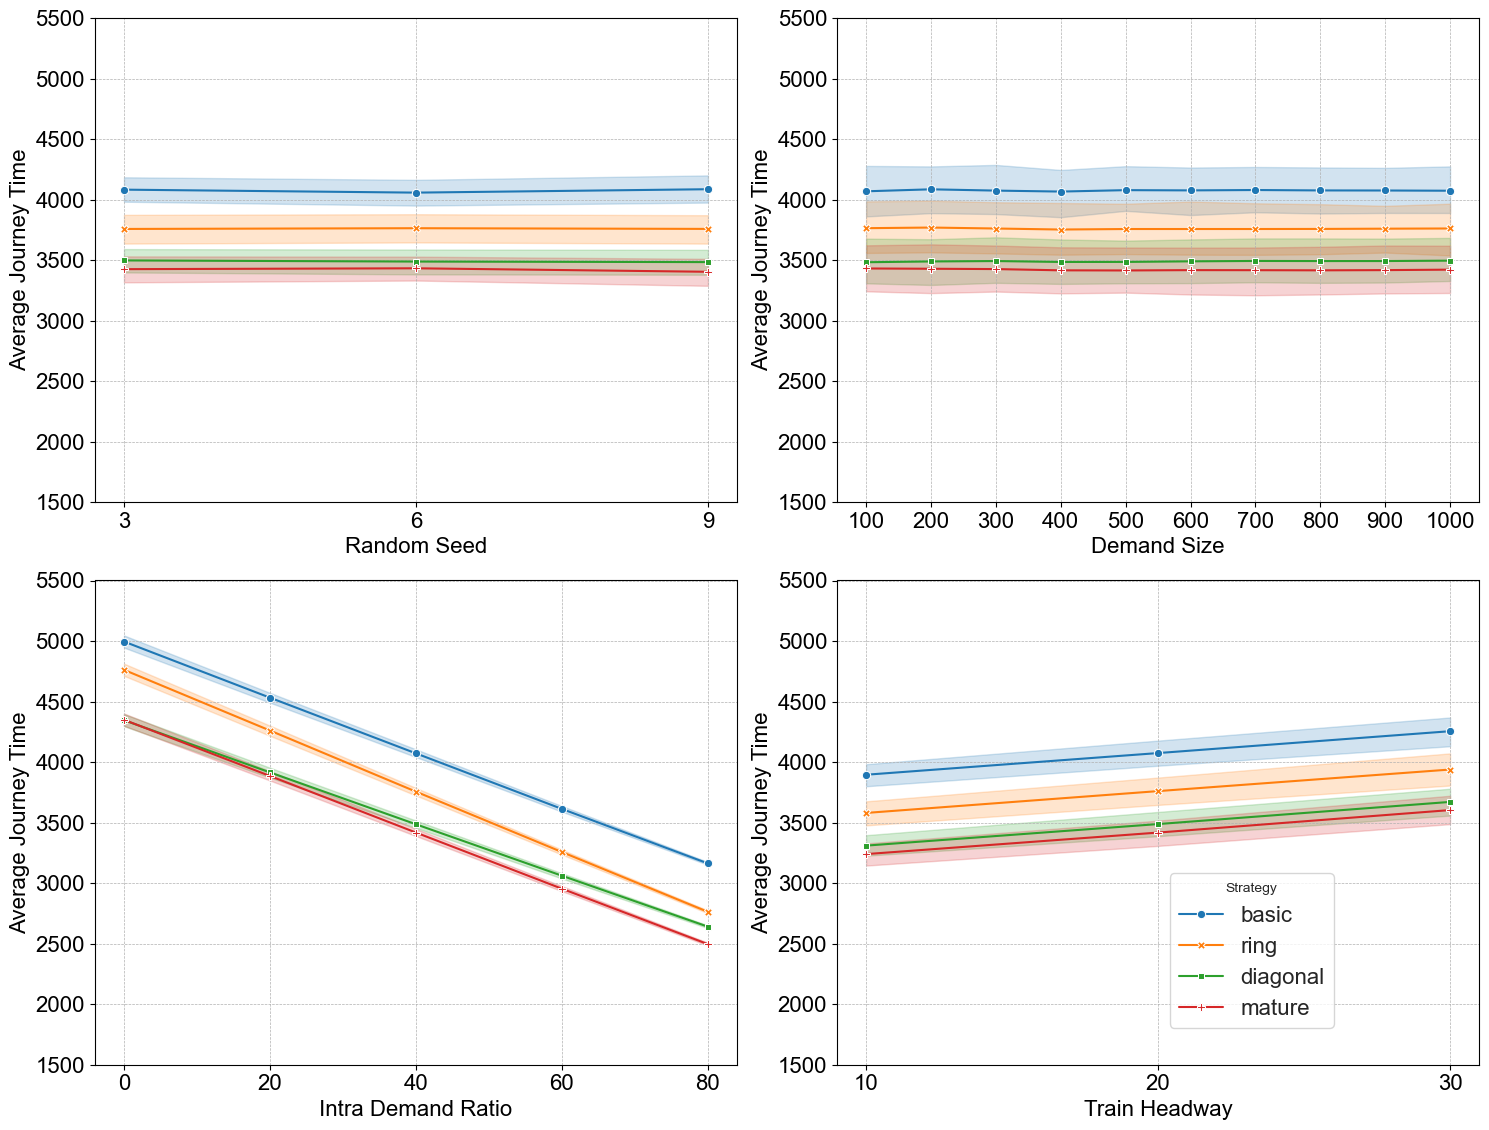

In [6]:
draw_interaction_plots(kpi_column='average_journey_time', y_axis_limit=(1500, 5500), data=pt_scenarios_results, strategy_column='pt_network_name')

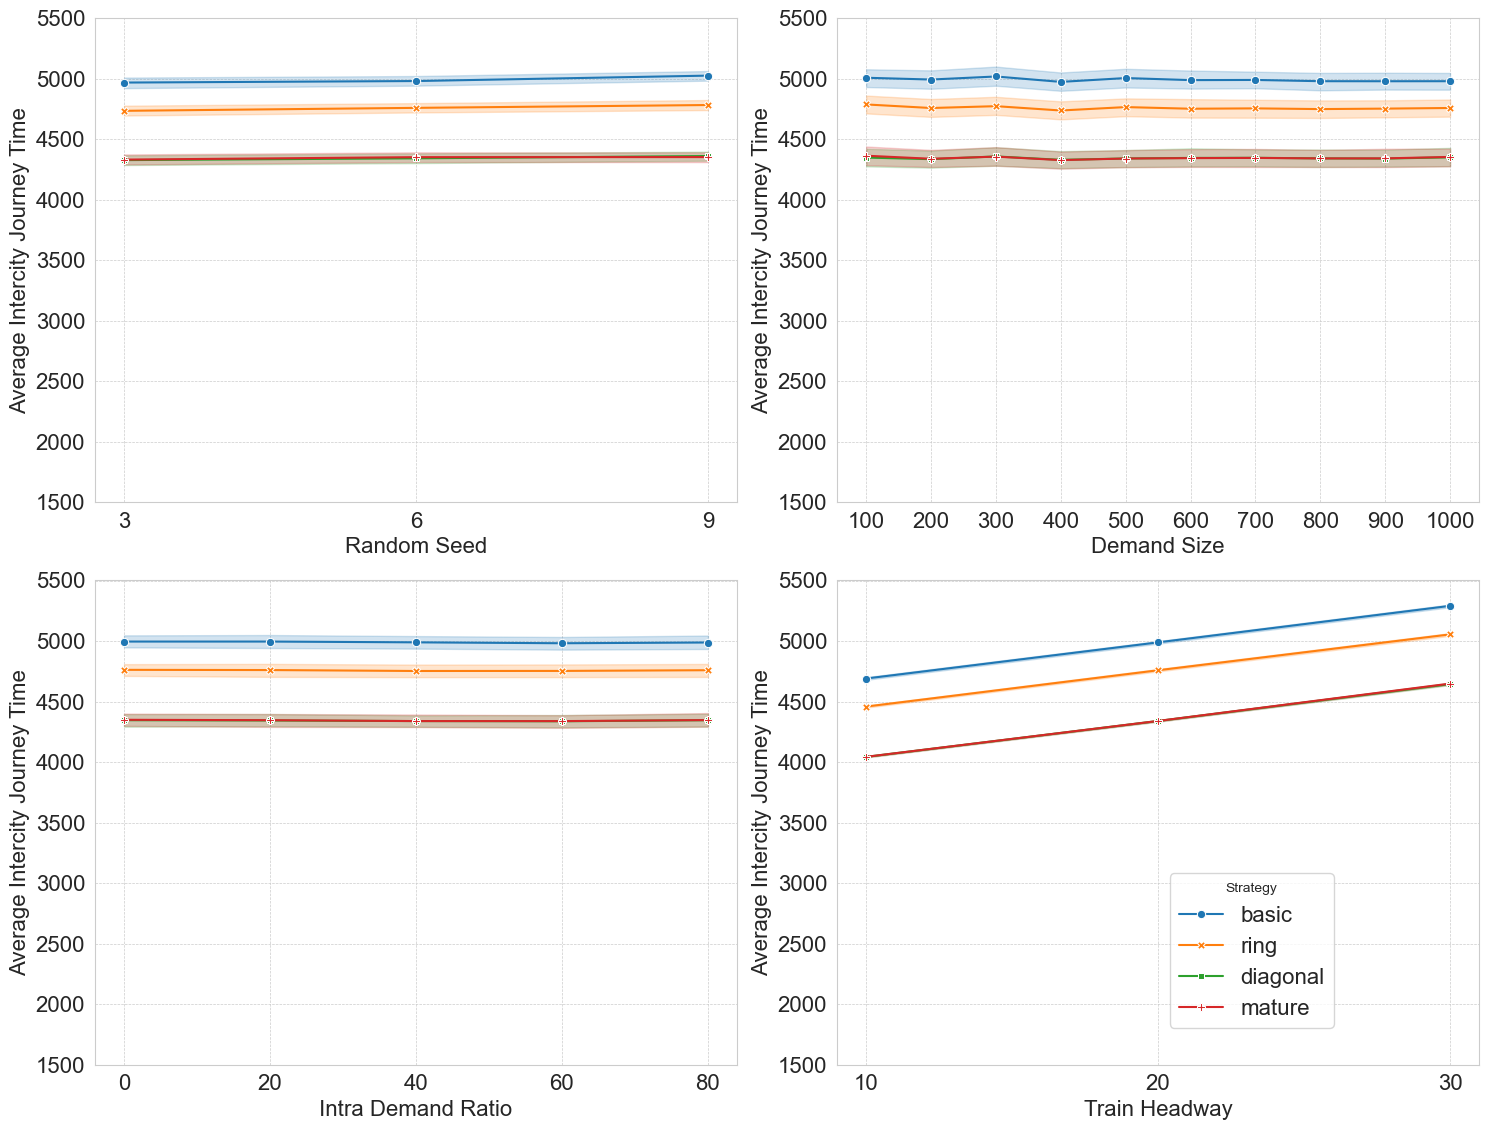

In [7]:
draw_interaction_plots(kpi_column='average_intercity_journey_time', y_axis_limit=(1500, 5500), data=pt_scenarios_results, strategy_column='pt_network_name')

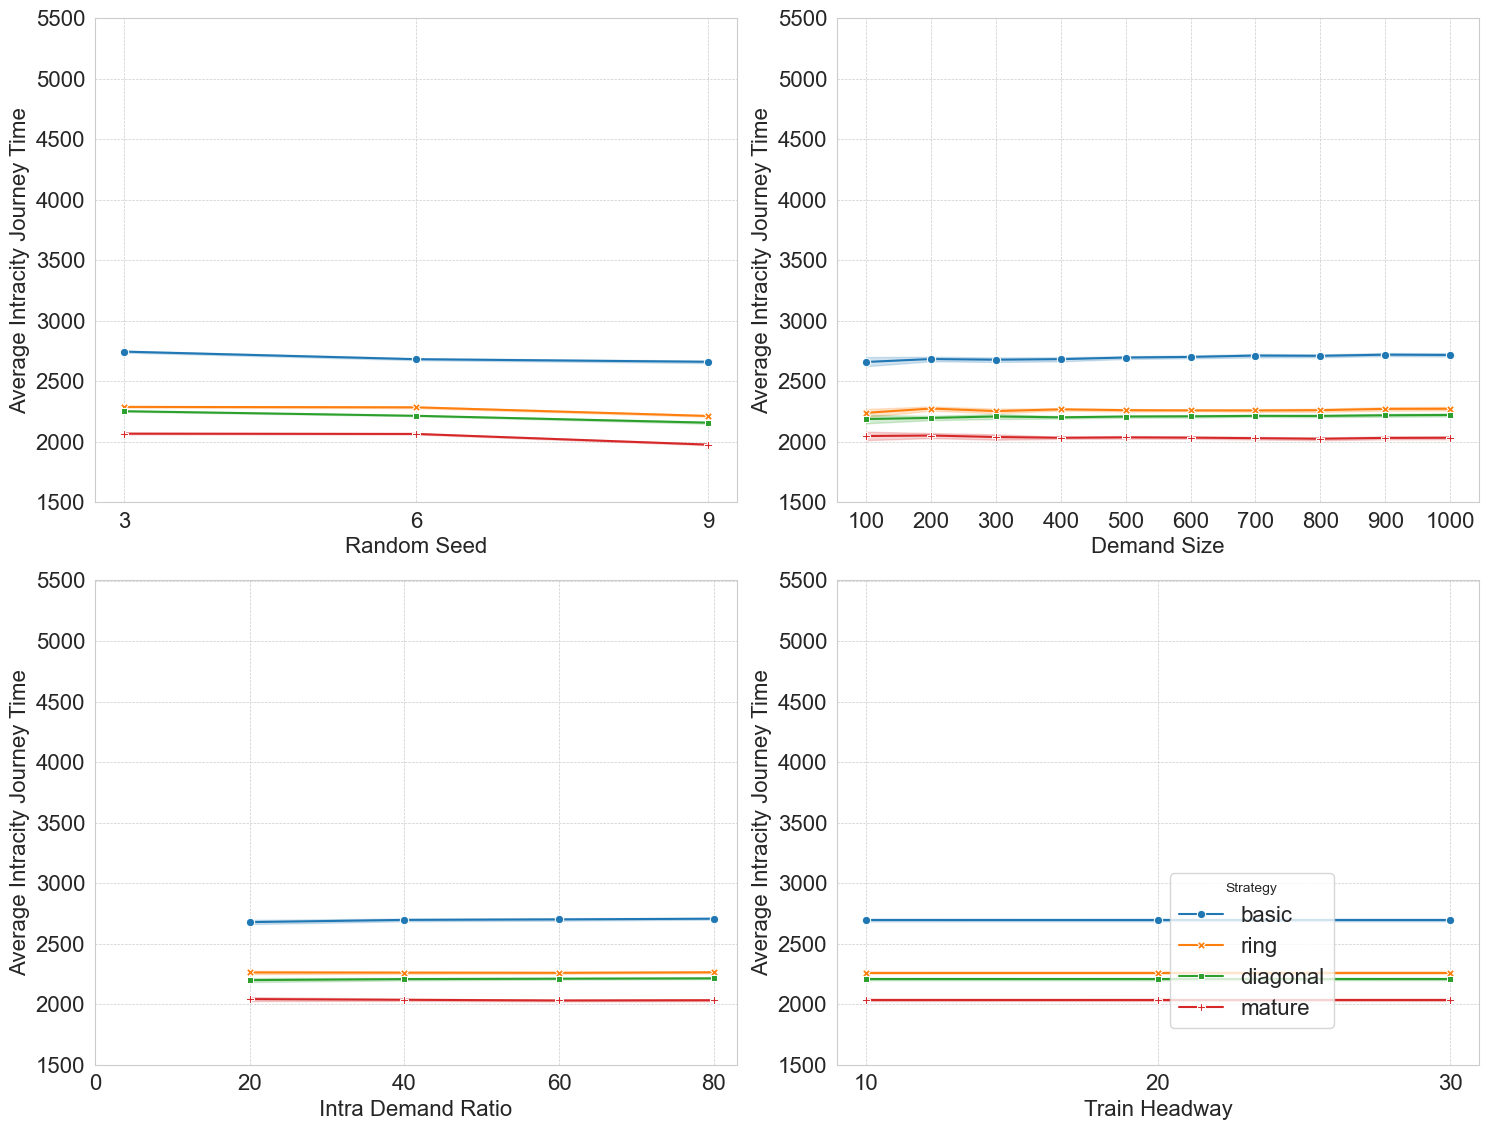

In [8]:
draw_interaction_plots(kpi_column='average_intracity_journey_time', y_axis_limit=(1500, 5500), data=pt_scenarios_results, strategy_column='pt_network_name')

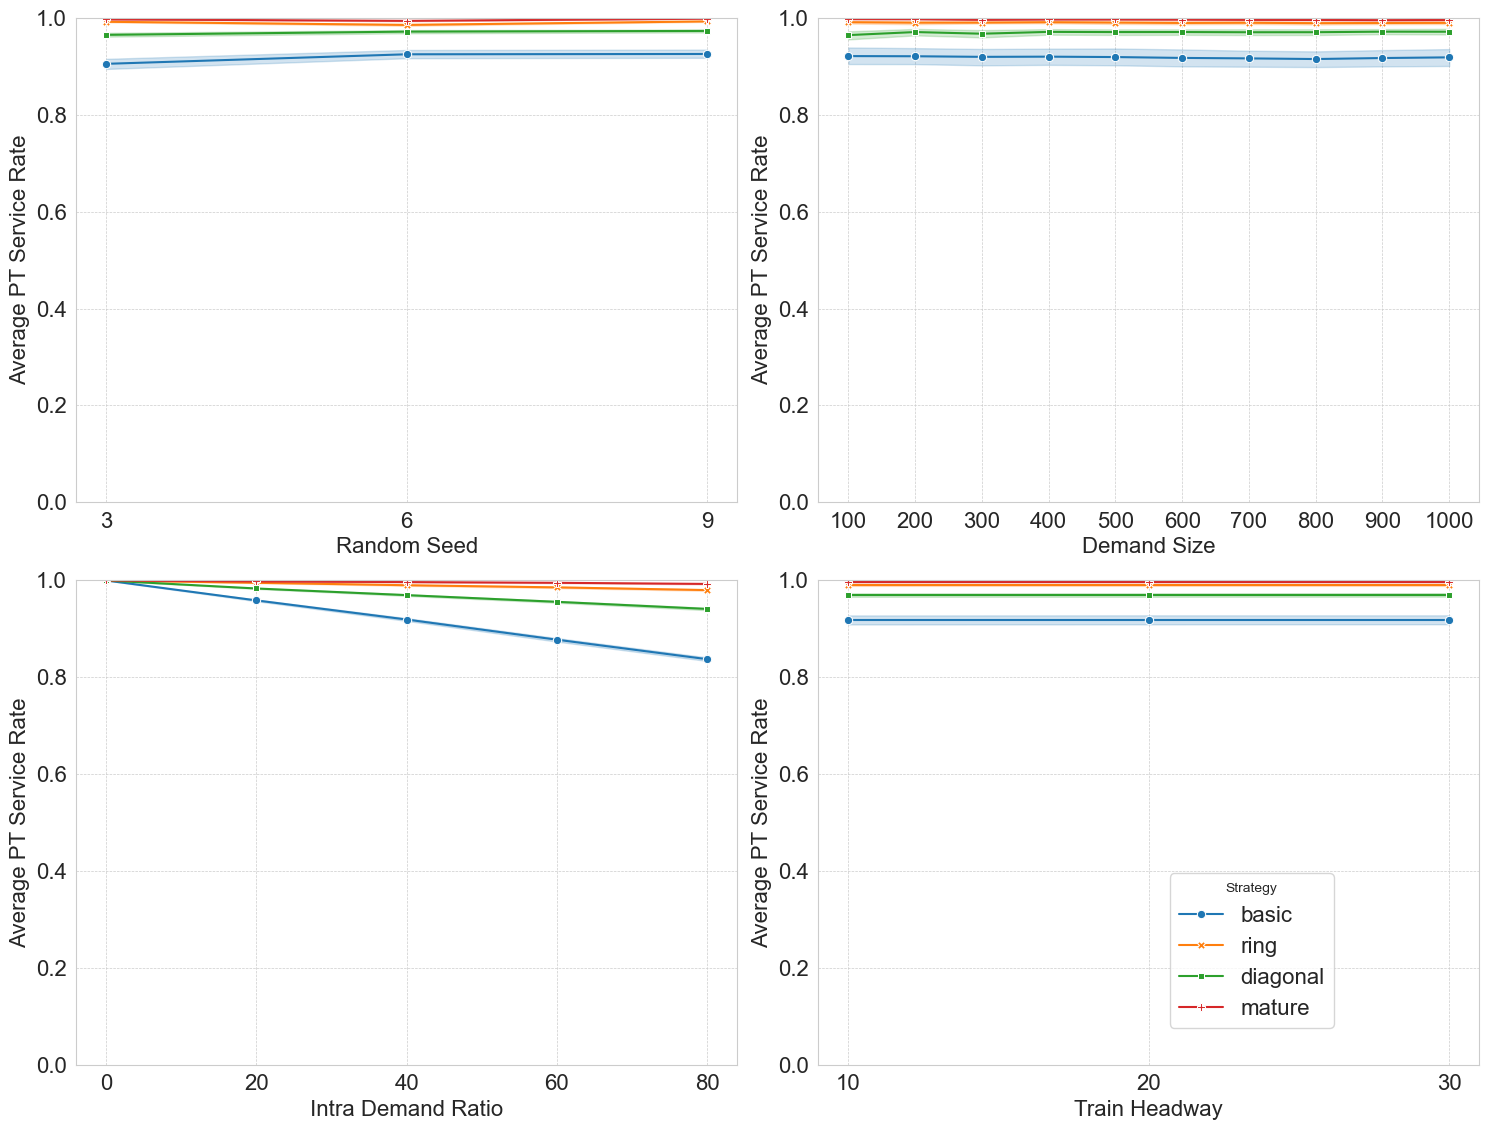

In [9]:
draw_interaction_plots(kpi_column='average_pt_service_rate', y_axis_limit=(0, 1), data=pt_scenarios_results, strategy_column='pt_network_name')